# Introduction to Bayesian Inverse Problems

This demo introduces the Bayesian formulation of an inverse problem: infer an unknown quantity $u$ from noisy observations $y$ generated by

$$
y = G(u) + \eta .
$$

The prior $\rho(u)$ represents information about plausible unknowns before seeing data, the likelihood $\nu(y-G(u))$ scores how well a candidate explains the observation, and the posterior combines both:

$$
\pi^y(u) \propto \nu(y-G(u))\rho(u).
$$

Conditioning on observations reduces the uncertainty of the prior, but the posterior still retains uncertainty.

See Chapter 1, Section 1.1: Bayesian Inversion. For the empirical MNIST prior used below, see Chapter 3, Section 3.4.2: Empirical Approximation Of The Prior.


## Scalar posterior: prior, likelihood, and posterior

The scalar experiment shows how the forward map $G$ shapes the posterior. With a linear map, one noisy observation usually produces one posterior mode. With $G(u)=u^2$, the same observation may be explained by two different signs of $u$, producing a multimodal posterior.

**Parameter exploration.**

- Set `forward_map = "linear"` and move the `observation` slider. Observe how the posterior mean changes as the observation moves, and compare the posterior mean with the observation location.
- Set `forward_map = "quadratic"` and use a positive observation. The posterior should become bimodal because both $u=\sqrt{y}$ and $u=-\sqrt{y}$ explain the same noiseless observation. Think about why the posterior mean stays near zero even when the observation changes.

**Recommended test combinations.** Use these settings to compare identifiable, noisy, and multimodal inverse problems.

| Exp ID | Forward map | Observation | Prior std. | Noise std. | What to look for |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **1** | linear | 4.0 | 2.0 | 0.8 | One posterior mode pulled toward the data but still influenced by the prior. |
| **2** | linear | 4.0 | 2.0 | 2.0 | A wider likelihood gives a broader posterior and stronger prior influence. |
| **3** | quadratic | 4.0 | 2.0 | 0.8 | Two symmetric modes appear near $u=\pm 2$. |
| **4** | quadratic | 1.0 | 2.0 | 0.3 | Sharper bimodality near $u=\pm 1$. |
| **5** | quadratic | 0.2 | 2.0 | 0.8 | The two signs become harder to separate and the posterior mass moves toward zero. |


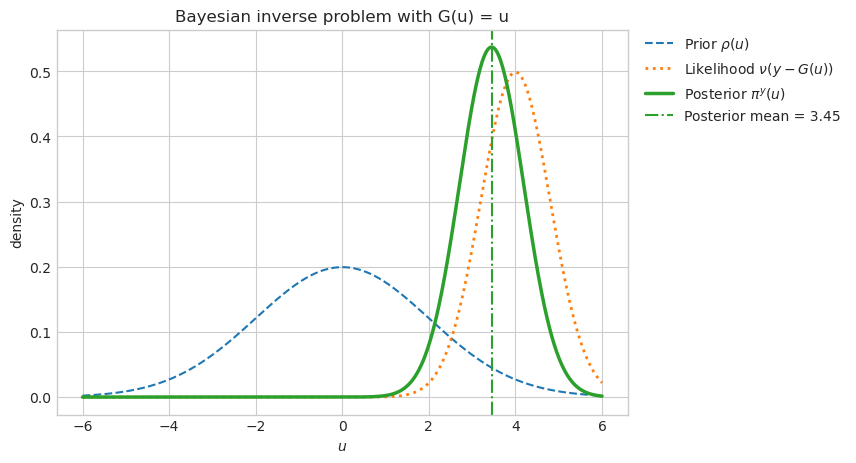

In [3]:
#@title Scalar Bayesian inverse problem
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")

DEFAULT_PARAMETERS = {
    "scalar_bayes": {
        "forward_map": "linear",
        "observation": 4.0,
        "prior_std": 2.0,
        "noise_std": 0.8,
    },
}

use_default = False #@param {type:"boolean"}
forward_map = "linear" #@param ["linear", "quadratic"]
observation = 4.0 #@param {type:"slider", min:-2.0, max:8.0, step:0.1}
prior_std = 2.0 #@param {type:"slider", min:0.2, max:5.0, step:0.1}
noise_std = 0.8 #@param {type:"slider", min:0.05, max:3.0, step:0.05}

if use_default:
    params = DEFAULT_PARAMETERS["scalar_bayes"]
    forward_map = params["forward_map"]
    observation = params["observation"]
    prior_std = params["prior_std"]
    noise_std = params["noise_std"]


def G(u, map_name):
    if map_name == "linear":
        return u
    if map_name == "quadratic":
        return u**2
    raise ValueError(f"Unknown forward_map: {map_name}")


u_grid = np.linspace(-6.0, 6.0, 2000)
prior = norm.pdf(u_grid, loc=0.0, scale=prior_std)
likelihood = norm.pdf(observation, loc=G(u_grid, forward_map), scale=noise_std)
posterior_unnormalized = prior * likelihood
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
normalizer = integrate(posterior_unnormalized, u_grid)
posterior = posterior_unnormalized / normalizer

posterior_mean = integrate(u_grid * posterior, u_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(u_grid, prior, "--", label=r"Prior $\rho(u)$")
ax.plot(u_grid, likelihood, ":", linewidth=2, label=r"Likelihood $\nu(y-G(u))$")
ax.plot(u_grid, posterior, linewidth=2.5, label=r"Posterior $\pi^y(u)$")
ax.axvline(posterior_mean, color="tab:green", linestyle="-.", label=f"Posterior mean = {posterior_mean:.2f}")

if forward_map == "quadratic" and observation > 0:
    root = np.sqrt(observation)
    ax.axvline(root, color="0.5", alpha=0.35)
    ax.axvline(-root, color="0.5", alpha=0.35)

ax.set_xlabel(r"$u$")
ax.set_ylabel("density")
ax.set_title(f"Bayesian inverse problem with G(u) = {'u' if forward_map == 'linear' else 'u^2'}")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.subplots_adjust(right=0.76)
plt.show()

## MNIST inpainting as an empirical Bayesian inverse problem

The unknown $u$ is a full $28\times 28$ digit image. The observation operator $G$ reveals one half of the image and hides the other half, so many complete digits can be compatible with the same data. Instead of using a pretrained inpainting model, we use MNIST training images as empirical prior samples. Each candidate image $u^{(i)}$ is ranked by the Gaussian likelihood

$$
w_i \propto \exp\left(-\frac{\|G(u^{(i)})-y\|^2}{2\sigma^2}\right).
$$

The examples below use noisy half-image observations. Each observation direction has a built-in group of easily confused target digits, and the code scans several held-out test images to choose examples whose six nearest posterior candidates show relatively rich variation.

**Parameter exploration.**

- Change `observed_half` and compare the posterior candidates. Different halves reveal different digit features, so the plausible completions and labels should change.
- Increase `noise_std`. Because the posterior candidates still come from the empirical MNIST prior, higher noise makes the observed half less decisive and the selected samples should become more diverse or more ambiguous rather than turning into arbitrary images.

**Recommended test combinations.** Compare how the visible half and noise level change the empirical posterior candidates.

| Exp ID | Observed half | Noise std. | What to look for |
| :--- | :--- | :---: | :--- |
| **1** | right | 0.05 | The posterior samples are similar to the observation in the observed half image. |
| **2** | top | 0.05 | The posterior samples are similar to the observation in the observed half image. |
| **5** | right | 0.20 | Higher noise should produce more diverse or ambiguous candidates. |


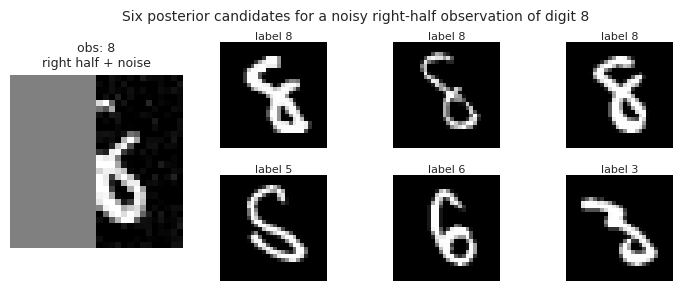

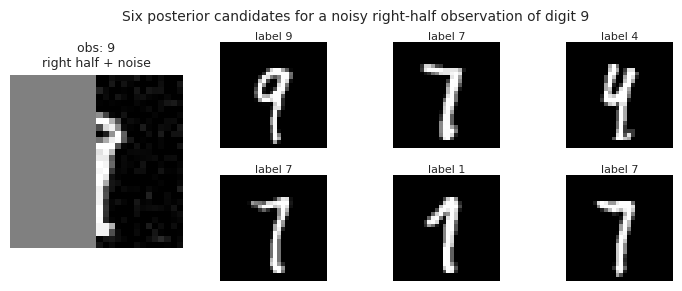

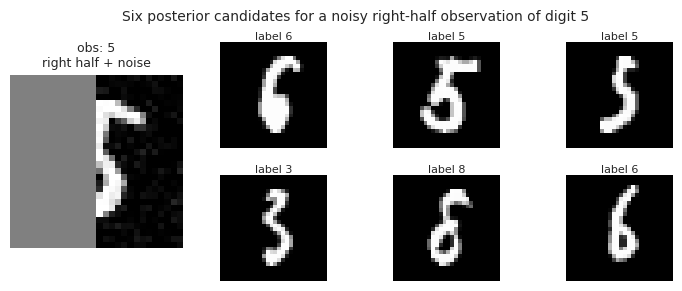

In [4]:
#@title MNIST empirical-prior inpainting
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

DEFAULT_PARAMETERS = {
    "mnist_inpainting": {
        "data_dir": "data",
        "observed_half": "right",
        "target_digits_by_half": {
            "right": [8, 9, 5],
            "left": [3, 8, 9],
            "top": [4, 7, 9],
            "bottom": [3, 5, 8],
        },
        "n_prior_samples": 60000,
        "target_search_per_digit": 120,
        "noise_seed": 11,
        "noise_std": 0.05,
    },
}

use_default = False #@param {type:"boolean"}
observed_half = "right" #@param ["right", "left", "top", "bottom"]
noise_std = 0.05 #@param {type:"slider", min:0.0, max:0.35, step:0.01}

params = DEFAULT_PARAMETERS["mnist_inpainting"]
if use_default:
    observed_half = params["observed_half"]
    noise_std = params["noise_std"]

data_dir = params["data_dir"]
target_digits = params["target_digits_by_half"][observed_half]
n_prior_samples = params["n_prior_samples"]
target_search_per_digit = params["target_search_per_digit"]
noise_seed = params["noise_seed"]

try:
    from torchvision.datasets import MNIST
    from torchvision import transforms
except ImportError:
    %pip install -q torch torchvision
    from torchvision.datasets import MNIST
    from torchvision import transforms


def mnist_arrays(root):
    transform = transforms.ToTensor()
    train = MNIST(root=root, train=True, download=True, transform=transform)
    test = MNIST(root=root, train=False, download=True, transform=transform)

    train_images = train.data.numpy().astype(np.float32) / 255.0
    train_labels = train.targets.numpy()
    test_images = test.data.numpy().astype(np.float32) / 255.0
    test_labels = test.targets.numpy()
    return train_images, train_labels, test_images, test_labels


def half_mask(shape, side):
    mask = np.zeros(shape, dtype=bool)
    h, w = shape
    if side == "right":
        mask[:, w // 2 :] = True
    elif side == "left":
        mask[:, : w // 2] = True
    elif side == "top":
        mask[: h // 2, :] = True
    elif side == "bottom":
        mask[h // 2 :, :] = True
    else:
        raise ValueError(f"Unknown observed_half: {side}")
    return mask


def pairwise_image_diversity(images):
    flat = images.reshape(len(images), -1)
    distances = []
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            distances.append(np.mean((flat[i] - flat[j]) ** 2))
    return float(np.mean(distances)) if distances else 0.0


def choose_target_case(
    digit,
    test_images,
    test_labels,
    candidate_images,
    candidate_labels,
    candidate_obs,
    candidate_norm2,
    mask,
    top_k,
    max_targets,
    base_noise_seed,
    sigma,
):
    target_indices = np.flatnonzero(test_labels == digit)[:max_targets]
    if len(target_indices) == 0:
        raise ValueError(f"No MNIST test images found for digit {digit}")

    clean_obs = test_images[target_indices][:, mask].astype(np.float32)
    rng = np.random.default_rng(base_noise_seed + 1009 * int(digit))
    noisy_obs = np.clip(
        clean_obs + rng.normal(0.0, sigma, size=clean_obs.shape),
        0.0,
        1.0,
    ).astype(np.float32)

    obs_norm2 = np.sum(noisy_obs * noisy_obs, axis=1)
    dist2 = obs_norm2[:, None] + candidate_norm2[None, :] - 2.0 * noisy_obs @ candidate_obs.T
    dist2 = np.maximum(dist2, 0.0)

    nearest = np.argpartition(dist2, top_k - 1, axis=1)[:, :top_k]
    nearest_dist = dist2[np.arange(len(target_indices))[:, None], nearest]
    order = np.argsort(nearest_dist, axis=1)
    nearest = nearest[np.arange(len(target_indices))[:, None], order]
    nearest_dist = nearest_dist[np.arange(len(target_indices))[:, None], order]

    best_score = -np.inf
    best_row = 0
    for row, top_indices in enumerate(nearest):
        labels = candidate_labels[top_indices]
        unique_labels = len(np.unique(labels))
        visual_diversity = pairwise_image_diversity(candidate_images[top_indices])
        contains_target = int(digit in labels)
        contains_three_and_eight = int(digit == 8 and 3 in labels and 8 in labels)
        score = (
            100.0 * unique_labels
            + 20.0 * contains_target
            + 60.0 * contains_three_and_eight
            + 1000.0 * visual_diversity
            - 0.01 * float(np.mean(nearest_dist[row]))
        )
        if score > best_score:
            best_score = score
            best_row = row

    chosen_index = int(target_indices[best_row])
    observed = np.full_like(test_images[chosen_index], 0.5)
    observed[mask] = noisy_obs[best_row]
    return {
        "digit": int(digit),
        "target_index": chosen_index,
        "observation": observed,
        "top_indices": nearest[best_row],
    }


train_images, train_labels, test_images, test_labels = mnist_arrays(data_dir)
mask = half_mask(train_images[0].shape, observed_half)

top_k = 6
n_prior_samples = int(min(max(n_prior_samples, top_k), len(train_images)))
target_search_per_digit = int(max(1, target_search_per_digit))

candidate_indices = np.arange(n_prior_samples)
candidates = train_images[candidate_indices]
candidate_labels = train_labels[candidate_indices]
candidate_obs = candidates[:, mask].astype(np.float32)
candidate_norm2 = np.sum(candidate_obs * candidate_obs, axis=1)

cases = [
    choose_target_case(
        digit=digit,
        test_images=test_images,
        test_labels=test_labels,
        candidate_images=candidates,
        candidate_labels=candidate_labels,
        candidate_obs=candidate_obs,
        candidate_norm2=candidate_norm2,
        mask=mask,
        top_k=top_k,
        max_targets=target_search_per_digit,
        base_noise_seed=noise_seed,
        sigma=noise_std,
    )
    for digit in target_digits
]

for case in cases:
    fig = plt.figure(figsize=(7.0, 2.8), constrained_layout=True)
    gs = fig.add_gridspec(2, 4, width_ratios=[1.05, 1, 1, 1])

    ax_obs = fig.add_subplot(gs[:, 0])
    ax_obs.imshow(case["observation"], cmap="gray", vmin=0, vmax=1)
    ax_obs.set_title(f"obs: {case['digit']}\n{observed_half} half + noise", fontsize=9)
    ax_obs.axis("off")

    for rank, idx in enumerate(case["top_indices"]):
        row, col = divmod(rank, 3)
        ax = fig.add_subplot(gs[row, col + 1])
        ax.imshow(candidates[idx], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"label {int(candidate_labels[idx])}", fontsize=8, pad=1)
        ax.axis("off")

    fig.suptitle(
        f"Six posterior candidates for a noisy {observed_half}-half observation of digit {case['digit']}",
        fontsize=10,
    )
    plt.show()

The left panel in each figure is the noisy data $y$: only the selected half of a held-out MNIST digit is observed. The six smaller panels are empirical-prior samples whose observed halves are closest under the Gaussian likelihood. The built-in digit choices are intentionally ambiguous, so candidates can include different plausible completions. This shows the same Bayesian point: with only partial noisy data, the posterior is a set of plausible completions rather than a single guaranteed reconstruction.

## Image denoising and deblurring as MAP estimation

A standard finite-dimensional linear inverse problem has the form

$$
y = G(u) + \eta,
$$

where $u$ is an unknown image, $G$ is a known linear observation operator, and $\eta$ is additive Gaussian noise. In image denoising, $G=I$, so the observation is a noisy version of the image. In image deblurring, $G$ is a blur operator; here it is a fixed Gaussian convolution, so high-frequency edge information is partly removed before noise is added.

The reconstruction below is a maximum a posteriori (MAP) estimate with a total variation (TV) prior. The TV seminorm $\|\nabla u\|_1$ is related to the prior, which encourages images that are mostly smooth but can still contain sharp edges. The displayed estimate approximates

$$
u_{\mathrm{MAP}} = \operatorname*{argmin}_u \left\{\frac{1}{2}\|G(u)-y\|^2 + \lambda \|\nabla u\|_1\right\}.
$$

The parameter `noise_std` is the standard deviation of the added Gaussian noise. The parameter `tv_weight` is the regularization strength $\lambda$: larger values impose stronger TV smoothing.

**Parameter exploration.**

- Switch `task` between denoising and deblurring. Deblurring should be harder because the forward operator removes image detail before the noise is added.
- Increase `noise_std`. The observation becomes less informative, and a larger `tv_weight` is usually needed to suppress noise.
- Increase `tv_weight`. Small values leave more noise or blur artifacts, while large values preserve broad edges but can flatten fine texture and contrast.
- Compare `image_name = "cameraman"` with `image_name = "text"`. The text image has very sparse sharp edges, so the TV prior is especially well matched to it.

**Recommended test combinations.** Use these settings to separate the effects of the forward operator, noise, and TV regularization.

| Exp ID | Image | Task | Noise std. | TV weight | What to look for |
| :--- | :--- | :--- | :---: | :---: | :--- |
| **1** | cameraman | denoising | 0.10 | 0.08 | Baseline denoising with edges mostly preserved. |
| **2** | cameraman | denoising | 0.25 | 0.15 | Stronger regularization should suppress heavier noise but flatten texture. |
| **3** | cameraman | deblurring | 0.10 | 0.08 | Major edges can sharpen, but lost high frequencies remain difficult. |
| **4** | cameraman | deblurring | 0.20 | 0.18 | More noise and blur require stronger smoothing, often at the cost of detail. |
| **5** | text | denoising | 0.10 | 0.08 | Sparse sharp strokes should be well matched to TV regularization. |
| **6** | text | deblurring | 0.10 | 0.12 | Text edges should recover better than fine natural-image texture. |


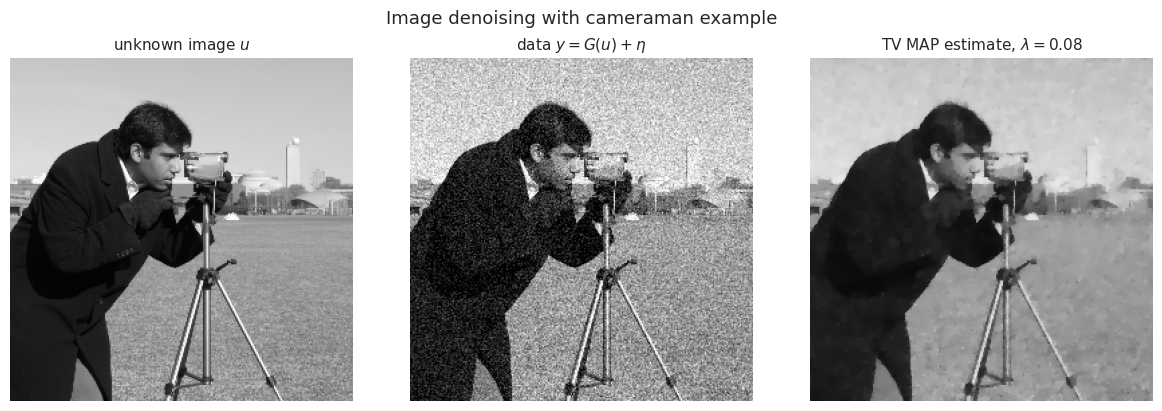

In [5]:
#@title TV MAP image denoising and deblurring
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

DEFAULT_PARAMETERS = {
    "tv_image_inverse_problem": {
        "image_name": "cameraman",
        "task": "denoising",
        "noise_std": 0.10,
        "tv_weight": 0.08,
        "random_seed": 7,
        "blur_sigma": 2.0,
        "n_deblur_iterations": 45,
        "gradient_step_size": 0.9,
    },
}

use_default = False #@param {type:"boolean"}
image_name = "cameraman" #@param ["cameraman", "text"]
task = "denoising" #@param ["denoising", "deblurring"]
noise_std = 0.10 #@param {type:"slider", min:0.0, max:0.4, step:0.01}
tv_weight = 0.08 #@param {type:"slider", min:0.01, max:0.35, step:0.01}

params = DEFAULT_PARAMETERS["tv_image_inverse_problem"]
if use_default:
    image_name = params["image_name"]
    task = params["task"]
    noise_std = params["noise_std"]
    tv_weight = params["tv_weight"]

random_seed = params["random_seed"]
blur_sigma = params["blur_sigma"]
n_deblur_iterations = params["n_deblur_iterations"]
gradient_step_size = params["gradient_step_size"]

try:
    from skimage import data, img_as_float
    from skimage.restoration import denoise_tv_chambolle
    from scipy.ndimage import gaussian_filter
except ImportError:
    %pip install -q scikit-image scipy
    from skimage import data, img_as_float
    from skimage.restoration import denoise_tv_chambolle
    from scipy.ndimage import gaussian_filter


def make_text_image(size=128):
    image = np.zeros((size, size), dtype=float)

    image[40:90, 10:20] = 1.0
    image[40:50, 10:40] = 1.0
    image[80:90, 10:40] = 1.0

    image[40:90, 50:60] = 1.0
    image[40:90, 80:90] = 1.0
    image[40:50, 60:80] = 1.0
    image[50:70, 65:75] = 1.0

    image[40:50, 100:125] = 1.0
    image[60:70, 100:125] = 1.0
    image[80:90, 100:125] = 1.0
    image[40:65, 100:110] = 1.0
    image[65:90, 115:125] = 1.0
    return image


def load_demo_image(name):
    if name == "cameraman":
        return img_as_float(data.camera())[::2, ::2]
    if name == "text":
        return make_text_image()
    raise ValueError(f"Unknown image_name: {name}")


def blur_operator(image):
    return gaussian_filter(image, sigma=blur_sigma, mode="reflect")


def tv_map_reconstruction(observation, task_name):
    if task_name == "denoising":
        return denoise_tv_chambolle(observation, weight=tv_weight, channel_axis=None)

    estimate = observation.copy()
    for _ in range(n_deblur_iterations):
        residual = blur_operator(estimate) - observation
        gradient = blur_operator(residual)
        estimate = estimate - gradient_step_size * gradient
        estimate = denoise_tv_chambolle(
            np.clip(estimate, 0.0, 1.0),
            weight=gradient_step_size * tv_weight,
            channel_axis=None,
        )
    return np.clip(estimate, 0.0, 1.0)


rng = np.random.default_rng(random_seed)
truth = load_demo_image(image_name)
clean_observation = truth if task == "denoising" else blur_operator(truth)
observation = np.clip(
    clean_observation + rng.normal(0.0, noise_std, size=truth.shape),
    0.0,
    1.0,
)
reconstruction = tv_map_reconstruction(observation, task)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

panels = [
    (truth, r"unknown image $u$"),
    (observation, r"data $y=G(u)+\eta$"),
    (reconstruction, rf"TV MAP estimate, $\lambda={tv_weight:.2f}$"),
]

for ax, (image, title) in zip(axes, panels):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle(f"Image {task} with {image_name} example", fontsize=13)
plt.show()
